In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression


In [9]:
df=pd.read_csv('vehicles.csv')
df = df.drop(columns=['id','url','region_url','image_url','description','county','lat','long','vin','region','model'])
df.head()

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
0,6995,2000.0,gmc,excellent,8 cylinders,gas,167783.0,clean,automatic,4wd,NaN,NaN,red,mn
1,8750,2013.0,hyundai,excellent,4 cylinders,gas,90821.0,clean,automatic,fwd,NaN,NaN,grey,mn
2,10900,2013.0,toyota,good,4 cylinders,hybrid,92800.0,clean,automatic,fwd,NaN,NaN,blue,ct
3,12500,2003.0,mitsubishi,good,4 cylinders,gas,NaN,clean,manual,4wd,mid-size,sedan,grey,nm
4,16995,2007.0,gmc,good,8 cylinders,diesel,254217.0,clean,automatic,4wd,full-size,truck,white,mn


In [15]:
df.isnull().sum()
df=df.dropna(subset=['year','odometer'])
df.head()

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
0,6995,2000.0,gmc,excellent,8 cylinders,gas,167783.0,clean,automatic,4wd,NaN,NaN,red,mn
1,8750,2013.0,hyundai,excellent,4 cylinders,gas,90821.0,clean,automatic,fwd,NaN,NaN,grey,mn
2,10900,2013.0,toyota,good,4 cylinders,hybrid,92800.0,clean,automatic,fwd,NaN,NaN,blue,ct
4,16995,2007.0,gmc,good,8 cylinders,diesel,254217.0,clean,automatic,4wd,full-size,truck,white,mn
5,13995,2012.0,ford,good,6 cylinders,gas,188406.0,clean,automatic,4wd,full-size,truck,grey,mn


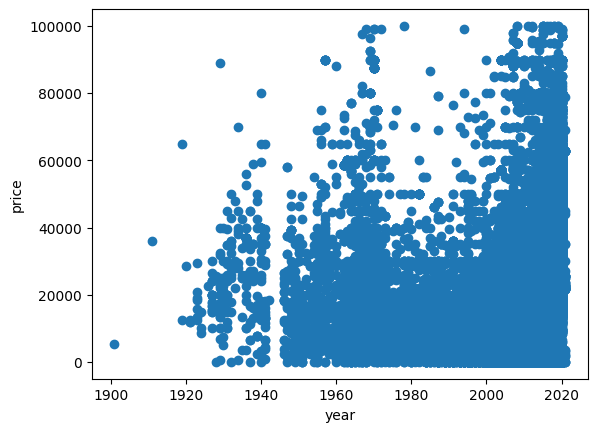

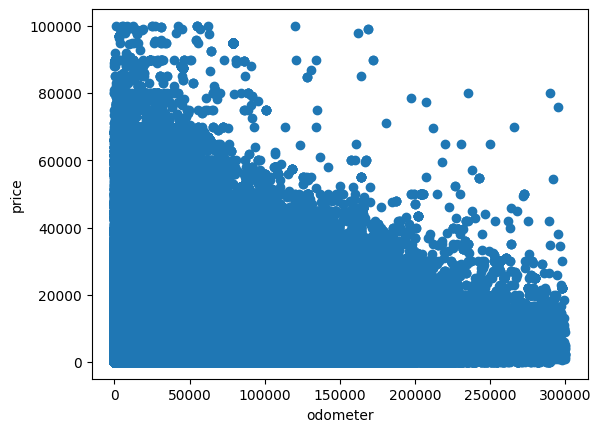

Text(0, 0.5, 'price')

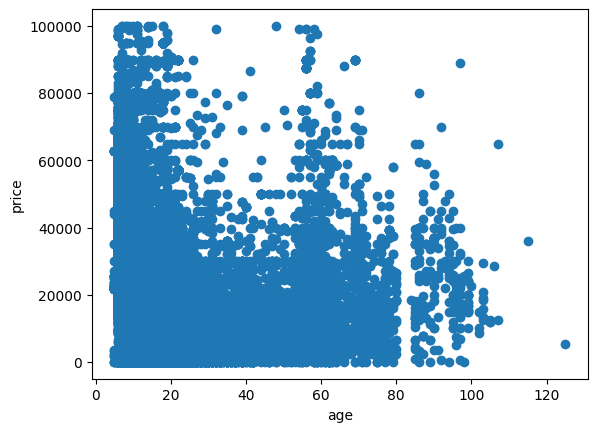

In [16]:
filtered_df=df[
    (df['price']<100000) &
    (df['odometer']<300000)
    ]
plt.scatter(filtered_df['year'],filtered_df['price'])
plt.xlabel("year")
plt.ylabel("price")
plt.show()
plt.scatter(filtered_df['odometer'],filtered_df['price'])
plt.xlabel("odometer")
plt.ylabel("price")
plt.show()
filtered_df['age']=2026-filtered_df['year']
plt.scatter(filtered_df['age'],filtered_df['price'])
plt.xlabel("age")
plt.ylabel("price")

In [20]:
x=filtered_df[['age','year','odometer']].values
y=filtered_df['price'].values

In [21]:
linear_model = LinearRegression()
linear_model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
b=linear_model.intercept_
w=linear_model.coef_
print("w",w,"b",b )

w [-1.18124407e+02  1.18124407e+02 -8.07879045e-02] b -213441.02213842893


In [24]:
print(np.dot(x[1],w)+b)
print(y[1])

15470.553278697305
8750
